# Analyzing simple weather data 
**Objective**: 

- Summarize weather patterns by city and season to support high-level operational planning.
- Identify time periods or cities with extreme or volatile weather conditions that may affect public services or infrastructure readiness.
- Detect trends and shifts in climate patterns using rolling averages and seasonal decomposition.
- Explore relationships between temperature, humidity, wind, and precipitation to uncover potential drivers of extreme conditions.
- Present insights visually and narratively in a way that is clear, accessible, and decision-focused.

**Dataset(s)**: 

Found on Kaggle ([source](https://www.kaggle.com/datasets/prasad22/weather-data)), this dataset contains 1 million records in a 99 MB `CSV` file. 

The data recorded is location, date and time, temperature, humidity, precipitation, and wind speed.

**Tools Used**:

Python
- pandas
- matplotlib
- numpy
- seaborn

## 1. Introduction

This project explores a fictional dataset containing weather measurements across multiple cities, including temperature, humidity, precipitation, wind speed, and timestamped records. The goal is to simulate a real-world data analysis workflow that supports actionable insights for stakeholders, such as city planners, business operators, or logistics managers.

Through this project, I demonstrate core competencies in exploratory data analysis (EDA), time-series analysis, data visualization, and stakeholder-style reporting. Emphasis is placed on identifying temporal trends, geographic differences, extreme events, and meaningful correlations between weather variables.

In [1]:
# Import packages and variables
import pandas as pd
import numpy as np
from numpy import sign
import matplotlib.pyplot as plt
import seaborn as sns
import re
from os.path import join
from IPython.display import HTML
from utilities.config import raw_data_path, processed_data_path, data_dir, weather_vars, processed_data_log_path

# Visualization settings
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
print(weather_vars)

['temperature', 'humidity', 'precipitation', 'windspeed']


## 2. Data Understanding

In [3]:
# Load data
df = pd.read_csv(raw_data_path, parse_dates=['Date_Time'])

# Preview data
df.head()

,Location,Date_Time,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
0,San Diego,2024-01-14 21:12:46,10.683001,41.195754,4.020119,8.233540
1,San Diego,2024-05-17 15:22:10,8.734140,58.319107,9.111623,27.715161
2,San Diego,2024-05-11 09:30:59,11.632436,38.820175,4.607511,28.732951
3,Philadelphia,2024-02-26 17:32:39,-8.628976,54.074474,3.183720,26.367303
4,San Antonio,2024-04-29 13:23:51,39.808213,72.899908,9.598282,29.898622


In [4]:
# Structure and summary
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   Location          1000000 non-null  object        
 1   Date_Time         1000000 non-null  datetime64[ns]
 2   Temperature_C     1000000 non-null  float64       
 3   Humidity_pct      1000000 non-null  float64       
 4   Precipitation_mm  1000000 non-null  float64       
 5   Wind_Speed_kmh    1000000 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 45.8+ MB


,Location,Date_Time,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
count,1000000,1000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
unique,10,NaN,NaN,NaN,NaN,NaN
top,Phoenix,NaN,NaN,NaN,NaN,NaN
freq,100209,NaN,NaN,NaN,NaN,NaN
mean,NaN,2024-03-10 10:40:58.896321792,14.779705,60.021830,5.109639,14.997598
min,NaN,2024-01-01 00:00:06,-19.969311,30.000009,0.000009,0.000051
25%,NaN,2024-02-04 16:28:23.750000128,2.269631,45.008500,2.580694,7.490101
50%,NaN,2024-03-10 11:43:28,14.778002,60.018708,5.109917,14.993777
75%,NaN,2024-04-14 03:51:32.500000,27.270489,75.043818,7.613750,22.514110
max,NaN,2024-05-18 19:44:10,39.999801,89.999977,14.971583,29.999973


### Summary

There does not seem to be any obvious issues with the data.

The data types make sense.

None of the records are missing any column values and the ranges of values found in each of the numeric columns appear to have no unusual or impossible values.

One thing that is interesting to note is that the mean and median for each numeric column is nearly identical. In a real-world situation, I think that would require closer scrutiny, as perfectly symmetrical weather data seems unlikely.

## 3. Data Cleaning & Preparation

In [5]:
# Rename columns to ease use
names = {
    'Location': 'location',
    'Date_Time': 'datetime',
    'Temperature_C': 'temperature',
    'Humidity_pct': 'humidity',
    'Precipitation_mm': 'precipitation',
    'Wind_Speed_kmh': 'windspeed'
}
df.rename(inplace=True, columns=names)
print(df.dtypes)


location                 object
datetime         datetime64[ns]
temperature             float64
humidity                float64
precipitation           float64
windspeed               float64
dtype: object


In [6]:
# Check for duplicate records
duplicates = df[df.duplicated(subset=['location', 'datetime'], keep=False)].sort_values(['location', 'datetime'])
display(duplicates)
duplicates.to_csv(join(data_dir, 'duplicates.csv')) # export to data file 'duplicates.csv'
print('Number of duplicate records: ', duplicates.shape[0])
print(duplicates.location.value_counts())

,location,datetime,temperature,humidity,precipitation,windspeed
138002,Chicago,2024-01-01 05:42:05,33.885939,51.196421,7.223224,23.560251
515729,Chicago,2024-01-01 05:42:05,-5.311788,79.611929,6.933497,2.759744
862891,Chicago,2024-01-01 06:56:45,0.861692,88.027134,3.701042,13.913699
875558,Chicago,2024-01-01 06:56:45,6.179934,86.207245,7.995065,16.488742
121537,Chicago,2024-01-01 08:15:35,0.224201,58.737580,8.984158,17.326420
...,...,...,...,...,...,...
991281,San Jose,2024-05-17 07:00:25,11.620164,61.997047,5.733704,28.898879
290407,San Jose,2024-05-18 06:18:47,13.168688,68.561387,5.019403,2.469587
770840,San Jose,2024-05-18 06:18:47,-1.436935,34.615755,2.212580,18.361293
68786,San Jose,2024-05-18 15:49:49,31.410860,58.393864,6.866484,12.475861


Number of duplicate records:  8221
location
Philadelphia    871
San Diego       867
Phoenix         861
Chicago         838
San Jose        838
Los Angeles     819
San Antonio     797
Houston         795
New York        791
Dallas          744
Name: count, dtype: int64


In [ ]:
# Calculate means to replace duplicated records
dup_mean = df.drop_duplicates(subset=['location', 'datetime']).groupby(['location', 'datetime']).agg('mean').reset_index() # TODO make sure that the correct value is being inserted here
display(dup_mean)
assert dup_mean.duplicated().sum() == 0

,location,datetime,temperature,humidity,precipitation,windspeed
0,Chicago,2024-01-01 05:42:05,14.287075,65.404175,7.078361,13.159997
1,Chicago,2024-01-01 06:56:45,3.520813,87.117190,5.848053,15.201221
2,Chicago,2024-01-01 08:15:35,14.079050,55.971951,5.288224,14.534819
3,Chicago,2024-01-01 19:52:32,21.151036,84.403052,4.856620,20.331755
4,Chicago,2024-01-01 21:15:26,8.155716,48.033175,3.037764,13.169007
...,...,...,...,...,...,...
4095,San Jose,2024-05-15 19:05:54,-3.509830,60.698656,4.022879,14.015743
4096,San Jose,2024-05-16 11:15:29,13.743265,79.665237,7.654933,13.141986
4097,San Jose,2024-05-17 07:00:25,6.087132,73.142743,5.941712,18.497535
4098,San Jose,2024-05-18 06:18:47,5.865877,51.588571,3.615991,10.415440


In [8]:
# Drop duplicates and concatenate unique records with calculated means for each column 
df_dropped = df.drop_duplicates(['location', 'datetime'], keep=False)
df = pd.concat([df_dropped, dup_mean])
df.reset_index(drop=True, inplace=True)
df.sort_values(['datetime', 'location'], inplace=True) # sort by datetime
assert df.duplicated().sum() == 0

In [9]:
# Transform data to make differences in values more pronounced
df_log = df[weather_vars].apply(lambda x: sign(x) + np.log10(abs(x) + 1))
# df_log.rename(columns=dict(zip(weather_vars, weather_vars_log)), inplace=True)
df_log = pd.concat([df[['location', 'datetime']], df_log], axis=1)
display(df_log)

,location,datetime,temperature,humidity,precipitation,windspeed
683438,Houston,2024-01-01 00:00:06,2.607127,2.553761,2.033733,2.331942
357781,Phoenix,2024-01-01 00:00:06,1.209135,2.680079,1.923224,1.800854
877302,Los Angeles,2024-01-01 00:00:15,2.567269,2.912680,1.269293,2.354770
623668,San Antonio,2024-01-01 00:00:18,2.519148,2.668165,1.590404,2.386243
700535,San Diego,2024-01-01 00:00:31,-0.041424,2.916309,1.808554,1.934996
...,...,...,...,...,...,...
977208,Chicago,2024-05-18 19:43:30,-0.591571,2.566575,1.991315,1.947075
214633,Philadelphia,2024-05-18 19:43:50,1.982179,2.949749,1.788013,2.355489
322076,New York,2024-05-18 19:43:55,1.938514,2.957615,1.889897,2.350583
802993,Houston,2024-05-18 19:44:02,2.544543,2.769047,1.287588,1.742773


In [10]:
# Export data and set df to point to logarithmic data
df_log.to_csv(processed_data_log_path, index=False)
df.to_csv(processed_data_path, index=False)
# df = df_log

### Summary

- I renamed the columns to make working with the data (a little) easier.
- There are no missing values.
- The data type for each column is appropriate and optimal for analysis.
- There are 4121 duplicated rows, based on "location" and "datetime". Because this is synthetic data generated from reasonable ranges in each location for a given time of year, I replaced the duplicate records with a single record which averaged the values of the duplicates. I then sorted the final product by date and time.

## 4. Exploratory Data Analysis (EDA)
- Distribution of variables
- Relationships between key features
- Business questions explored

### Distribution visualizations

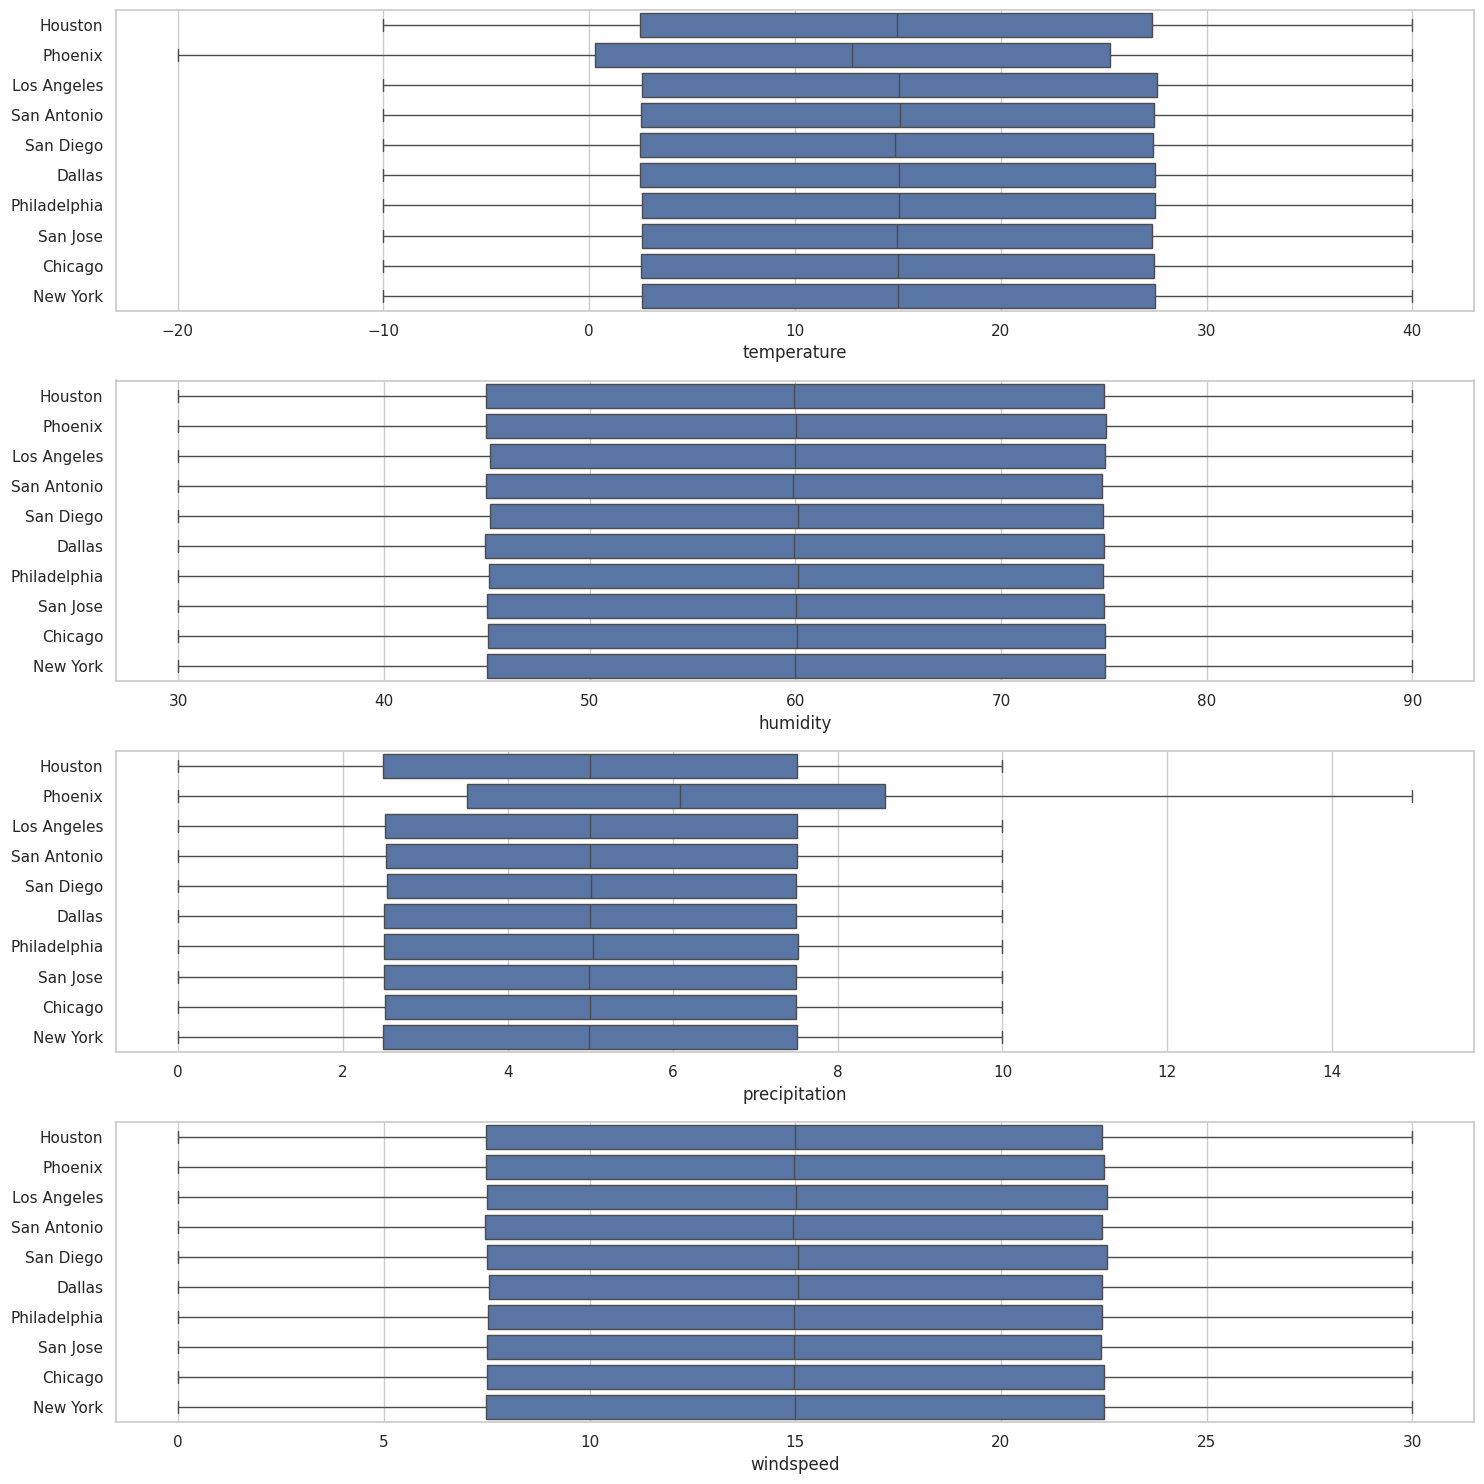

In [11]:
# Distribution of weather variables
fig, axes = plt.subplots(len(weather_vars), 1, figsize=(15,15))
la = zip(weather_vars, axes)
for l, a in la:
    sns.boxplot(df, x=l, y='location', ax=a)
    a.set_ylabel('')
plt.tight_layout()

Note:
There seems to be something unusual with Phoenix's data: it's distibution for "temperature" and "precipitation" contains values well outside of the physical norm. Also, Phoenix seems to be the odd one out when compared to other cities in terms of temperature and precipitation.

Additionally, these values seem pretty similar for cities that exist in very different climes (e.g. San Diego, CA and Chicago, IL).

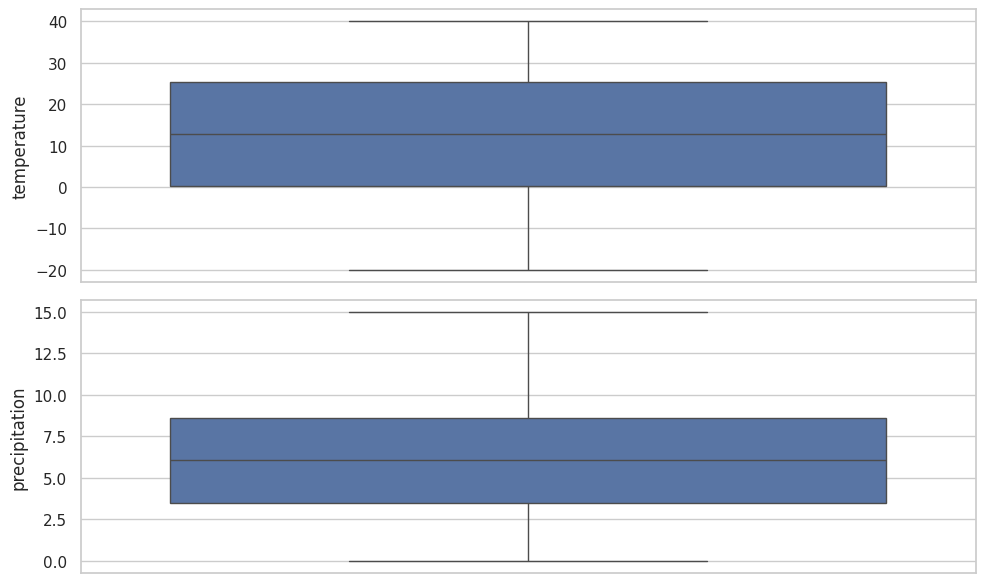

In [12]:
# Examine the distribution shape of Phoenix's temperature and precipitation data
df_phoenix = df.loc[df.location == 'Phoenix']
cols = ['temperature', 'precipitation']
fig, axes = plt.subplots(nrows=2)
la = zip(cols, axes)
for c, a in la:
    sns.boxplot(df_phoenix, y=c, ax=a)
plt.tight_layout()

Phoenix has some odd distibutions for these variables. I want to see how it compares to other "locations".

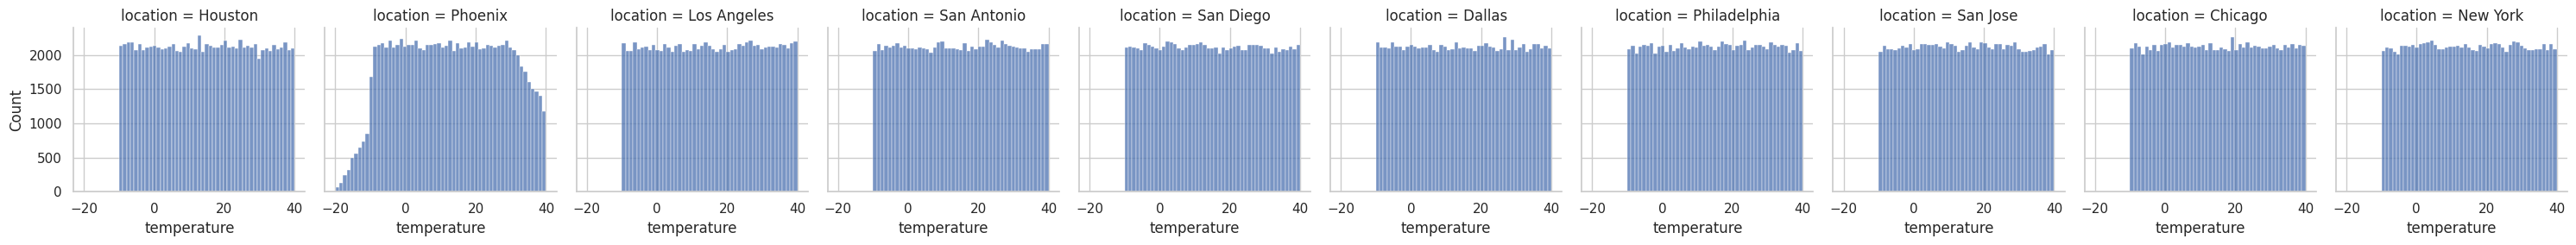

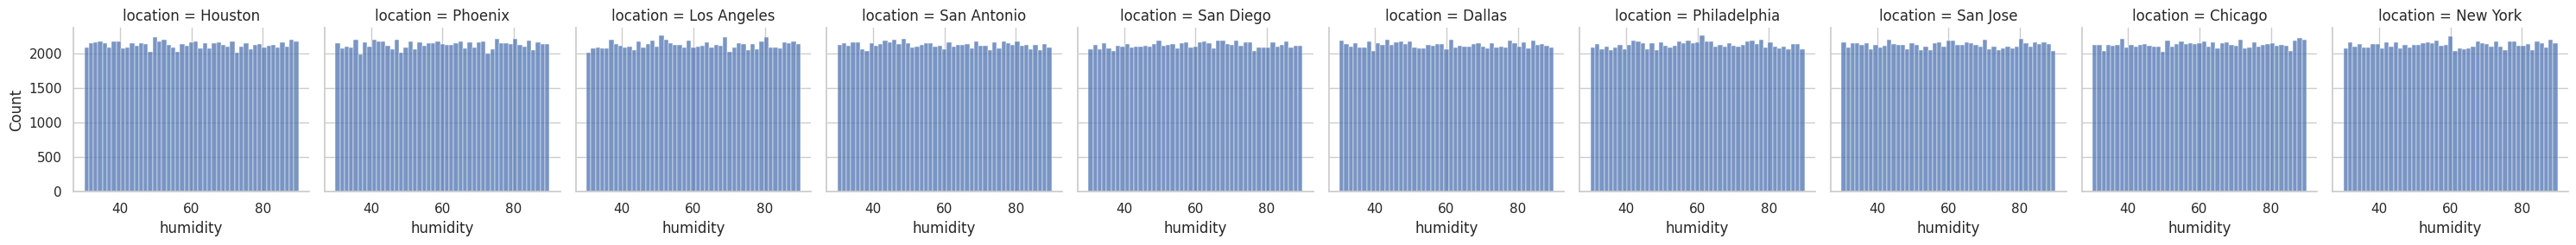

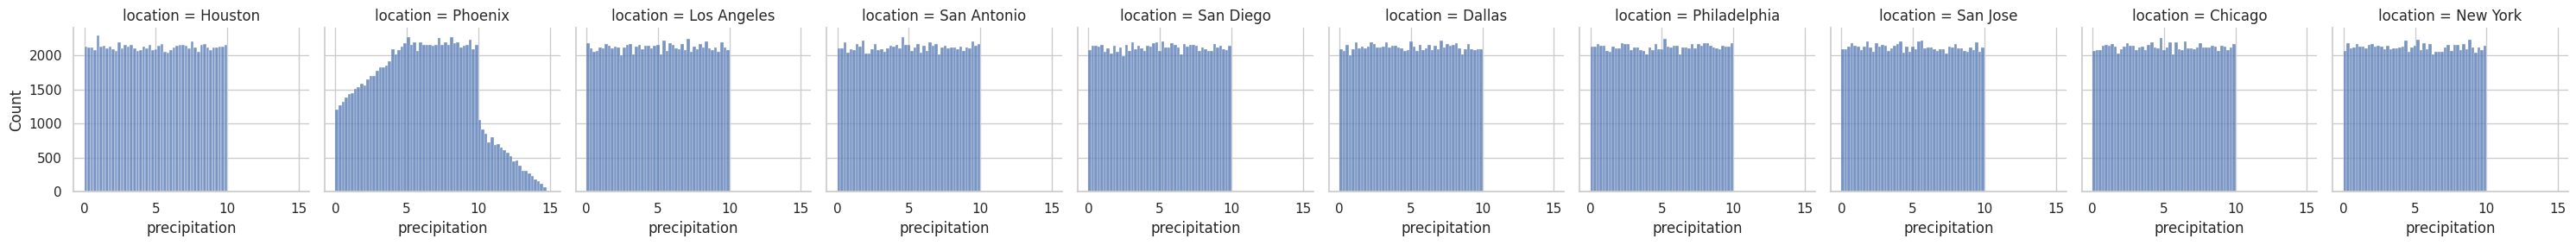

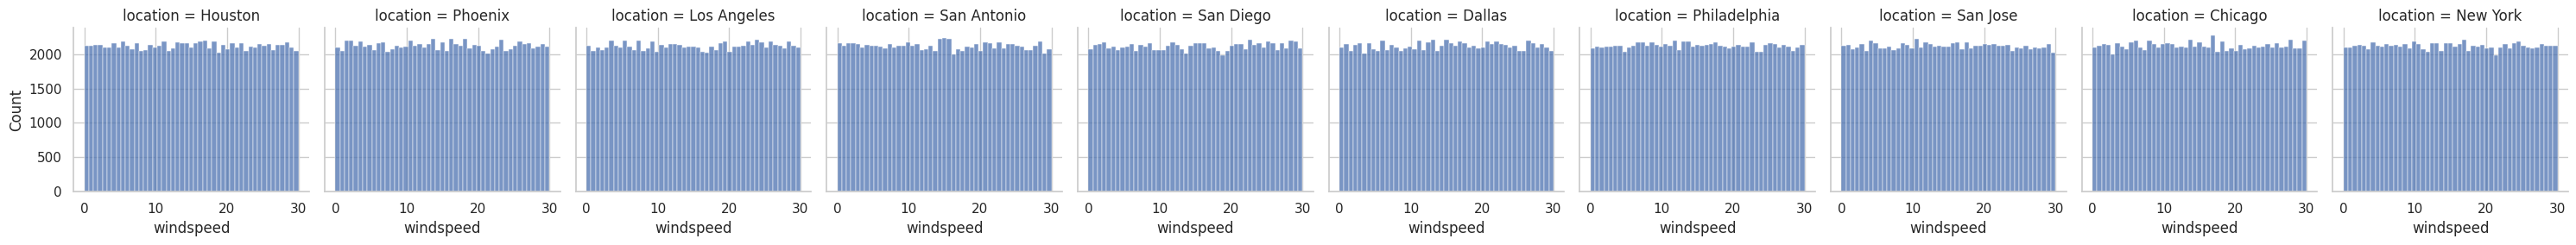

In [13]:
# Examine the distribution shape of all locations' temperature and precipitation data
for c in weather_vars:
    g = sns.FacetGrid(df, col='location')
    g.map(sns.histplot, c)
plt.show()

Most "locations" have a similar uniform distribution for the weather variables.
Phoenix is the odd one out, possessing many values below -10 degrees and many values above 10 mm of precipitation and missing values below 5 mm precipitation, relative to other "locations".

### Averages by "location"

Overall average by "location":


,temperature,humidity,precipitation,windspeed
location,,,,
Chicago,15.012022,60.083549,5.002662,14.996880
Dallas,15.006249,59.961771,4.998021,15.021181
Houston,14.943023,59.967978,4.997673,14.988226
Los Angeles,15.083142,60.077038,5.003857,15.036744
New York,15.014615,60.041484,4.992532,14.990003
Philadelphia,15.034143,60.040504,5.008494,14.992811
Phoenix,12.792731,60.048100,6.086957,14.984408
San Antonio,15.028135,59.928705,5.008214,14.956428
San Diego,14.931435,60.070727,5.007100,15.037212


Overall average by "location" for winter (2024-01-01 through 2024-03-19):


,temperature,humidity,precipitation,windspeed
location,,,,
Chicago,14.973418,59.989172,5.004569,14.984168
Dallas,14.916330,59.965300,4.992445,14.999354
Houston,14.941109,60.003554,4.994719,15.001508
Los Angeles,15.041370,60.068071,5.000432,15.021907
New York,14.994398,60.096840,4.994929,14.972072
Philadelphia,15.046893,60.033530,5.019946,15.014180
Phoenix,11.152697,59.998419,6.925420,15.022904
San Antonio,15.053892,59.972052,5.001410,14.955943
San Diego,14.943246,60.111047,4.999350,15.020649


Overall average by "location" for spring (2024-03-20 through 2024-05-18):


,temperature,humidity,precipitation,windspeed
location,,,,
Chicago,15.054567,60.205744,4.999727,15.020784
Dallas,15.125107,59.949459,5.006770,15.046723
Houston,14.950920,59.914536,5.002349,14.978879
Los Angeles,15.139370,60.076190,5.010673,15.061511
New York,15.033888,59.976691,4.989341,15.007410
Philadelphia,15.014226,60.041921,4.994101,14.967376
Phoenix,14.926042,60.103445,4.997385,14.934970
San Antonio,14.975931,59.873026,5.021674,14.949396
San Diego,14.913812,60.005483,5.015015,15.053100


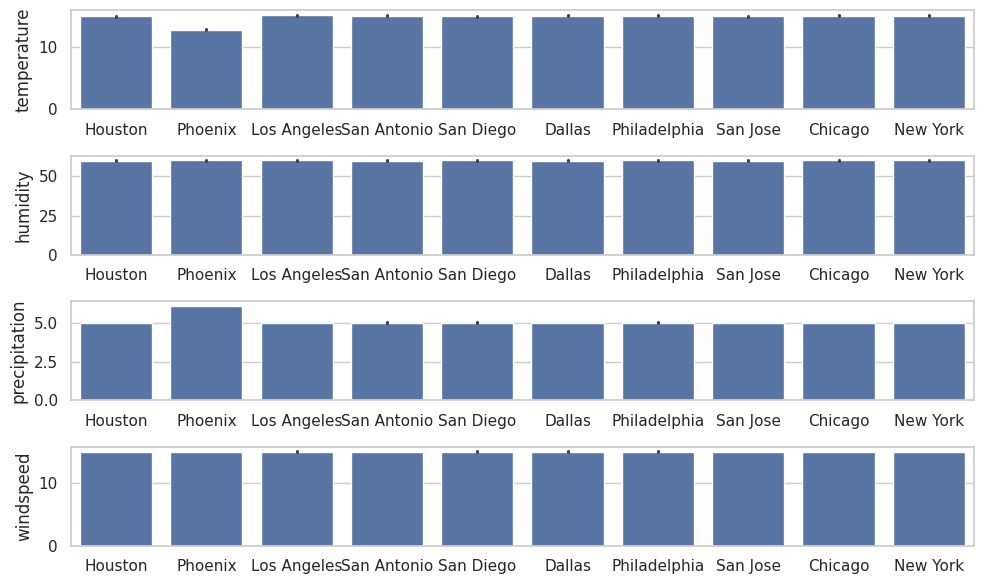

In [14]:
# Average for weather variables by "location"
print('Overall average by "location":')
display(df.groupby('location').agg('mean')[weather_vars])

# Average by season
first_date = df.datetime.min()
last_date = df.datetime.max()
spring_start = pd.to_datetime('2024-03-20')
winter_end = spring_start - pd.Timedelta(1, 'd')

print(f'Overall average by "location" for winter ({first_date.date()} through {winter_end.date()}):')
df_winter = df.loc[df.datetime.between(first_date, winter_end)]
display(df_winter.groupby('location').agg('mean')[weather_vars])

print(f'Overall average by "location" for spring ({spring_start.date()} through {last_date.date()}):')
df_spring = df.loc[df.datetime.between(spring_start, last_date)]
display(df_spring.groupby('location').agg('mean')[weather_vars])

# Visualization of averages
fig, axes = plt.subplots(nrows=len(weather_vars))
la = zip(weather_vars, axes)
for l, a in la:
    sns.barplot(df, x='location', y=l, ax=a)
    a.set_xlabel('')
plt.tight_layout()


In [15]:
# Maxes and mins for weather variables
print('Maximums:')
display(df.groupby('location').agg('max')[weather_vars])
print('Minimums:')
display(df.groupby('location').agg('min')[weather_vars])

Maximums:


,temperature,humidity,precipitation,windspeed
location,,,,
Chicago,39.998561,89.998857,9.999889,29.999889
Dallas,39.998804,89.999929,9.999968,29.999971
Houston,39.998913,89.999082,9.999921,29.999947
Los Angeles,39.999592,89.998014,9.999522,29.999757
New York,39.999801,89.999880,9.999992,29.999681
Philadelphia,39.999642,89.999332,9.999944,29.999973
Phoenix,39.998889,89.999666,14.971583,29.999392
San Antonio,39.998343,89.999637,9.999734,29.999800
San Diego,39.999692,89.998941,9.999716,29.999920


Minimums:


,temperature,humidity,precipitation,windspeed
location,,,,
Chicago,-9.999959,30.001637,0.000118,0.000171
Dallas,-9.999588,30.000572,0.000185,0.000342
Houston,-9.999874,30.000734,0.000010,0.000119
Los Angeles,-9.999913,30.000223,0.000153,0.000173
New York,-9.999870,30.000231,0.000331,0.000199
Philadelphia,-9.999282,30.000009,0.000454,0.000272
Phoenix,-19.969311,30.002950,0.000032,0.000090
San Antonio,-9.999964,30.000028,0.000149,0.000573
San Diego,-9.999986,30.001341,0.000089,0.000614


In [16]:
# Distribution of wind speeds by location


datetime  temperature   humidity  \
location     month                                                         
Chicago      1     2024-01-16 11:14:30.917490944    14.860229  59.985753   
             2     2024-02-15 13:43:50.317220352    15.121009  59.998639   
             3     2024-03-16 12:19:09.704468992    15.076371  60.204593   
             4     2024-04-16 01:16:06.786222848    15.091991  60.023860   
             5     2024-05-09 21:22:52.152899584    14.855531  60.277003   
Dallas       1     2024-01-16 13:08:25.623629824    14.931791  59.933118   
             2     2024-02-15 11:00:10.378156800    14.978184  60.091013   
             3     2024-03-16 11:42:31.883630848    14.830816  59.933271   
             4     2024-04-15 22:49:52.362301440    15.153468  59.860477   
             5     2024-05-09 21:15:59.923275776    15.239108  60.018756   
Houston      1     2024-01-16 12:15:43.943057920    14.892295  60.177237   
             2     2024-02-15 14:20:02.436193792    14.976678  59.881779   
             3     2024-03-16 11:23:12.216233216    14.973442  59.910397   
             4     2024-04-15 23:55:48.821834496    14.843200  59.808207   
             5     2024-05-09 20:59:52.154635008    15.092503  60.116545   
Los Angeles  1     2024-01-16 11:27:38.611041280    15.050216  60.035074   
             2     2024-02-15 11:34:15.501543424    14.994120  60.008065   
             3     2024-03-16 13:03:43.030151424    15.058329  60.105028   
             4     2024-04-15 21:18:00.409872640    15.085033  60.291702   
             5     2024-05-09 20:53:31.651383808    15.321599  59.854228   
New York     1     2024-01-16 11:29:34.205771776    14.910178  60.097754   
             2     2024-02-15 13:17:42.203655680    15.008949  60.088743   
             3     2024-03-16 11:13:55.000268800    15.100045  60.072489   
             4     2024-04-16 01:39:52.942513920    15.011290  59.981926   
             5     2024-05-09 20:05:50.808834816    15.060632  59.913621   
Philadelphia 1     2024-01-16 12:07:55.919126528    15.004885  59.944979   
             2     2024-02-15 15:03:32.010028544    15.040287  60.142714   
             3     2024-03-16 13:25:17.940139520    15.137004  60.015360   
             4     2024-04-15 23:14:46.807650048    14.947699  60.023996   
             5     2024-05-09 21:19:09.038699776    15.044606  60.114478   
Phoenix      1     2024-01-16 11:38:38.992955392     9.995423  59.994142   
             2     2024-02-15 12:10:41.223733504     9.990432  59.995351   
             3     2024-03-16 12:58:56.494876416    14.949193  59.998082   
             4     2024-04-15 22:52:51.550558720    14.947052  60.265990   
             5     2024-05-09 22:29:54.833938176    14.967793  59.953084   
San Antonio  1     2024-01-16 10:26:06.777552896    14.964531  59.836903   
             2     2024-02-15 09:43:27.768832512    15.155876  60.104743   
             3     2024-03-16 14:13:26.965567232    15.061373  59.959808   
             4     2024-04-16 00:26:31.796386816    15.017508  59.853477   
             5     2024-05-09 22:08:22.987676672    14.891554  59.878121   
San Diego    1     2024-01-16 10:38:19.811229440    15.003718  60.203561   
             2     2024-02-15 11:17:51.961647104    14.848061  60.214390   
             3     2024-03-16 12:08:27.791674112    14.947582  59.813429   
             4     2024-04-15 22:46:47.021028352    14.877103  59.973793   
             5     2024-05-09 23:37:32.007680256    15.008204  60.215781   
San Jose     1     2024-01-16 12:40:33.089254400    14.922482  59.975798   
             2     2024-02-15 10:47:09.227875072    14.968672  60.178504   
             3     2024-03-16 11:47:27.747086592    14.919241  59.820161   
             4     2024-04-16 01:22:34.993656064    15.035321  60.031463   
             5     2024-05-09 21:50:16.489711360    14.953374  59.911123   

                    precipitation  windspeed  
location     month                      

<Axes: xlabel='month', ylabel='temperature'>

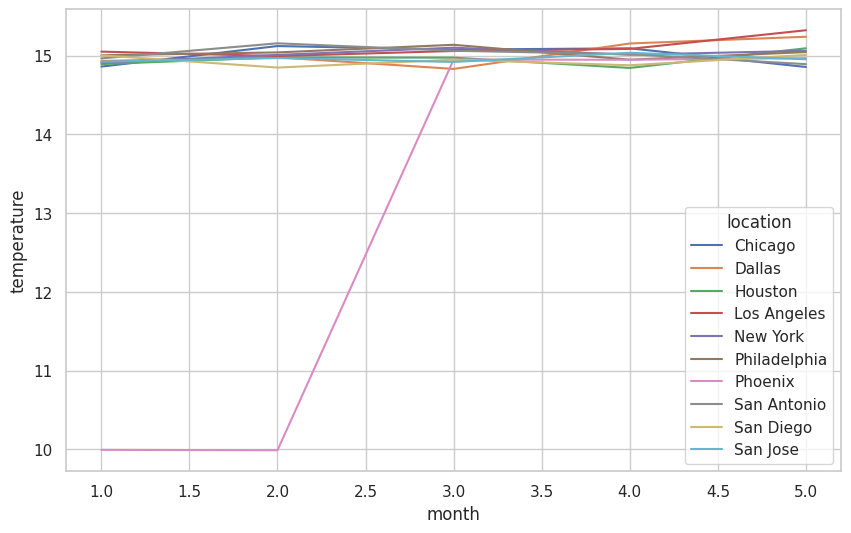

In [18]:
# Average temperature by month
df['month'] = df.datetime.dt.month
df.month = df.month.astype('int')
df_avg_temp = df.groupby(['location', 'month']).agg('mean')
display(df_avg_temp)
sns.lineplot(df_avg_temp, x='month', y='temperature', hue='location')

In [ ]:
# Correlation heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

## 5. Deeper Analysis or Modeling
- Trend analysis, segment analysis, KPIs
- Simple models if needed
- Explain business implications of findings

In [ ]:
# Example: Customer churn by segment
df.groupby('segment')['churn'].mean().sort_values(ascending=False)

## 6. Insights & Recommendations
- 🔹 Insight 1: ...
- 🔹 Insight 2: ...
- 🔹 Insight 3: ...
- ✅ Recommended Actions:
    - ...
    - ...

## 7. Conclusion
- Recap of goals and findings
- Limitations
- Suggestions for future work

## 8. Appendix
- Additional charts
- Definitions
- Notes on calculations